<a href="https://colab.research.google.com/github/VladimirSharaP/CV_CascadeClassifier/blob/main/CV_CascadeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

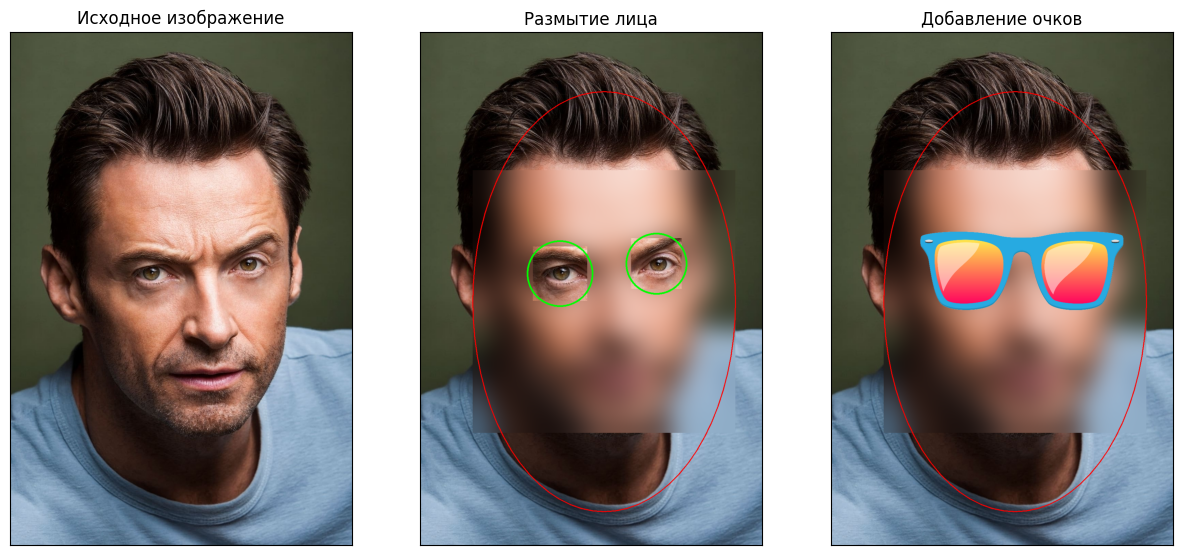

In [ ]:
import cv2
import gdown
from matplotlib import pyplot
import numpy as np
# Команда обеспечивает вывод графиков в Google Colaboratory
%matplotlib inline

gdown.download('https://www.film.ru/sites/default/files/people/1455531-2783777.jpg', None, quiet=True)
# Загрузка изображения
img = cv2.imread('./1455531-2783777.jpg')
img2 = img.copy()


glasses_mask = cv2.imread('/content/drive/MyDrive/3_1.png', cv2.IMREAD_UNCHANGED)
h_mask, w_mask = glasses_mask.shape[:2]


def blur_face(img):
  (h, w) = img.shape[:2]
  dW = int(w / 3.0)
  dH = int(h / 3.0)
  if dW % 2 == 0:
      dW -= 1
  if dH % 2 == 0:
      dH -= 1
  return cv2.GaussianBlur(img, (dW, dH), 0)

# загрузка каскада Хаара
classifier = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_frontalface_default.xml")

# выполнение распознавания лиц
bboxes = classifier.detectMultiScale(img, scaleFactor=2, minNeighbors=3, minSize=(50, 50))

# загрузка каскада Хаара для поиска глаз
classifier_eye = cv2.CascadeClassifier(cv2.data.haarcascades+ "haarcascade_eye.xml")

# формирование прямоугольника вокруг каждого обнаруженного лица
for box in bboxes:
    # формирование координат
    x, y, width, height = box
    x2, y2 = x + width/2, y + height/2

    face = img2[y:y + height, x:x + width]

    eyes = classifier_eye.detectMultiScale(face, minSize=(50, 50))

    roi = blur_face(face)

    x_eye1 = int((eyes[0][0]+eyes[0][2]) * 1.15)
    y_eye1 = int((eyes[0][1]+eyes[0][3]) * 1.2)
    x_eye2 = int(eyes[1][0] * 0.6)
    y_eye2 = int(eyes[1][1] * 0.8)
    roi_eyes = roi[y_eye2:y_eye1, x_eye2:x_eye1]


    face_height, face_width = roi_eyes.shape[:2]
    sunglass_img_resized = cv2.resize(glasses_mask, (face_width, face_height))

    alpha_sunglass = sunglass_img_resized[:, :, 3] / 255.0
    alpha_sunglass = np.stack([alpha_sunglass] * 3, axis=-1)

    sunglass_bgr = sunglass_img_resized[:, :, :3]

    overlay = (1 - alpha_sunglass) * roi_eyes + alpha_sunglass * sunglass_bgr

    for (x_eye,y_eye,w_eye,h_eye) in eyes:
        # определяем центр круга
        center = (int(x_eye + 0.5*w_eye), int(y_eye + 0.5*h_eye))
        # вычисляем радиус окружности (подобран эмпирическим путем)
        radius = int(0.3 * (w_eye + h_eye))
        color = (0, 255, 0) # цвет в RGB (интенсивность цветов красный-зеленый-синий от 0 до 255)
        thickness = 3 # толщина линии

        eye = face[y_eye:y_eye + h_eye, x_eye:x_eye + w_eye]
        mask = np.zeros_like(eye)

        roi[y_eye:y_eye + h_eye, x_eye:x_eye + w_eye] = cv2.bitwise_and(face[y_eye:y_eye + h_eye, x_eye:x_eye + w_eye], cv2.bitwise_not(mask)) + cv2.bitwise_and(eye, mask)

        # рисуем круг
        cv2.circle(roi, center, radius, color, thickness)

    img2[y:y+roi.shape[0], x:x+roi.shape[1]] = roi

    img3 = img2.copy()

    roi[y_eye2:y_eye1, x_eye2:x_eye1] = overlay

    img3[y:y+roi.shape[0], x:x+roi.shape[1]] = roi

    img2 = cv2.ellipse(img2, (int(x2), int(y2)), (int(width*0.5), int(height*0.8)), 0, 0, 360, (0, 0, 255), 2)
    img3 = cv2.ellipse(img3, (int(x2), int(y2)), (int(width*0.5), int(height*0.8)), 0, 0, 360, (0, 0, 255), 2)



fig, (ax1, ax2, ax3) = pyplot.subplots(1, 3, figsize=(15, 8))
ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax1.xaxis.set_ticks([])
ax1.yaxis.set_ticks([])
ax1.set_title('Исходное изображение')

ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.xaxis.set_ticks([])
ax2.yaxis.set_ticks([])
ax2.set_title('Размытие лица')

ax3.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
ax3.xaxis.set_ticks([])
ax3.yaxis.set_ticks([])
ax3.set_title('Добавление очков')

pyplot.show()